In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
from pyspark import SparkContext
from pyspark.ml.feature import StringIndexer
import seaborn as sns
from pyspark.sql.functions import col, sum, when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegressionModel
import os
#including libraries

In [2]:
spark = SparkSession.builder \
        .master("local") \
        .appName("ChurnModellemesi") \
        .config("spark.executer.memory", "24gb") \
        .getOrCreate()


sc = spark.sparkContext
#Creating and running a Spark session with its location, name, and custom settings.

In [3]:
sc

<SparkContext master=local appName=ChurnModellemesi>

In [4]:
spark_df = spark.read.csv("churn.csv",inferSchema=True,header=True,sep=",")

spark_df.cache()
# Opening the churn.csv file with the specified parameters and loading it into RAM.

DataFrame[_c0: int, Names: string, Age: double, Total_Purchase: double, Account_Manager: int, Years: double, Num_Sites: double, Churn: int]

In [5]:
spark_df.printSchema() # to be able to see the "features" and data types

root
 |-- _c0: integer (nullable = true)
 |-- Names: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Total_Purchase: double (nullable = true)
 |-- Account_Manager: integer (nullable = true)
 |-- Years: double (nullable = true)
 |-- Num_Sites: double (nullable = true)
 |-- Churn: integer (nullable = true)



In [6]:
spark_df.show(6)

+---+----------------+----+--------------+---------------+-----+---------+-----+
|_c0|           Names| Age|Total_Purchase|Account_Manager|Years|Num_Sites|Churn|
+---+----------------+----+--------------+---------------+-----+---------+-----+
|  0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|
|  1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|
|  2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|
|  3|   Phillip White|42.0|       8010.76|              0| 6.71|     10.0|    1|
|  4|  Cynthia Norton|37.0|       9191.58|              0| 5.56|      9.0|    1|
|  5|Jessica Williams|48.0|      10356.02|              0| 5.12|      8.0|    1|
+---+----------------+----+--------------+---------------+-----+---------+-----+
only showing top 6 rows


In [7]:
spark_df = spark_df.withColumnRenamed("_c0","index") #Rename column c0 to index.

In [8]:
spark_df.show(3)

+-----+----------------+----+--------------+---------------+-----+---------+-----+
|index|           Names| Age|Total_Purchase|Account_Manager|Years|Num_Sites|Churn|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
only showing top 3 rows


In [9]:
#lower
spark_df = spark_df.toDF(*[c.lower() for c in spark_df.columns])


In [10]:
spark_df.show(5)

+-----+----------------+----+--------------+---------------+-----+---------+-----+
|index|           names| age|total_purchase|account_manager|years|num_sites|churn|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
|    0|Cameron Williams|42.0|       11066.8|              0| 7.22|      8.0|    1|
|    1|   Kevin Mueller|41.0|      11916.22|              0|  6.5|     11.0|    1|
|    2|     Eric Lozano|38.0|      12884.75|              0| 6.67|     12.0|    1|
|    3|   Phillip White|42.0|       8010.76|              0| 6.71|     10.0|    1|
|    4|  Cynthia Norton|37.0|       9191.58|              0| 5.56|      9.0|    1|
+-----+----------------+----+--------------+---------------+-----+---------+-----+
only showing top 5 rows


In [11]:
spark_df.count()

900

In [12]:
len(spark_df.columns)

8

In [13]:
spark_df.distinct().count()

900

In [14]:
spark_df.select("names").distinct().count()

899

In [15]:
spark_df.groupby("names").count().show(5)

+----------------+-----+
|           names|count|
+----------------+-----+
|    Patrick Bell|    1|
|Patrick Robinson|    1|
|   Chelsea Marsh|    1|
|     John Barber|    1|
|     Amber Evans|    1|
+----------------+-----+
only showing top 5 rows


In [16]:
spark_df.groupby("names").count().sort("count",ascending = False).show(3)

+----------------+-----+
|           names|count|
+----------------+-----+
|   Jennifer Wood|    2|
|    Patrick Bell|    1|
|Patrick Robinson|    1|
+----------------+-----+
only showing top 3 rows


In [17]:
spark_df.filter(spark_df.names == "Jennifer Wood").show()

+-----+-------------+----+--------------+---------------+-----+---------+-----+
|index|        names| age|total_purchase|account_manager|years|num_sites|churn|
+-----+-------------+----+--------------+---------------+-----+---------+-----+
|   22|Jennifer Wood|35.0|       9381.12|              1| 6.78|     11.0|    1|
|  439|Jennifer Wood|48.0|      11585.16|              0| 4.61|      9.0|    0|
+-----+-------------+----+--------------+---------------+-----+---------+-----+



In [18]:
spark_df.select("names").drop_duplicates().groupby("names").count().sort("count",ascending=False).show(4)

+----------------+-----+
|           names|count|
+----------------+-----+
|    Patrick Bell|    1|
|Patrick Robinson|    1|
|   Chelsea Marsh|    1|
|     John Barber|    1|
+----------------+-----+
only showing top 4 rows


In [19]:
spark_df.where(spark_df.index == 439).select("names").show()

+-------------+
|        names|
+-------------+
|Jennifer Wood|
+-------------+



# Data Analysis

In [20]:
spark_df.describe().show()

+-------+------------------+-------------+-----------------+-----------------+------------------+-----------------+------------------+-------------------+
|summary|             index|        names|              age|   total_purchase|   account_manager|            years|         num_sites|              churn|
+-------+------------------+-------------+-----------------+-----------------+------------------+-----------------+------------------+-------------------+
|  count|               900|          900|              900|              900|               900|              900|               900|                900|
|   mean|             449.5|         NULL|41.81666666666667|10062.82403333334|0.4811111111111111| 5.27315555555555| 8.587777777777777|0.16666666666666666|
| stddev|259.95191863111916|         NULL|6.127560416916251|2408.644531858096|0.4999208935073339|1.274449013194616|1.7648355920350969| 0.3728852122772358|
|    min|                 0|   Aaron King|             22.0|          

In [21]:
spark_df.select("age","total_purchase", "account_manager", "years","num_sites","churn").describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,900,41.81666666666667,6.127560416916251,22.0,65.0
total_purchase,900,10062.82403333334,2408.644531858096,100.0,18026.01
account_manager,900,0.4811111111111111,0.4999208935073339,0,1
years,900,5.27315555555555,1.274449013194616,1.0,9.15
num_sites,900,8.587777777777777,1.7648355920350969,3.0,14.0
churn,900,0.16666666666666666,0.3728852122772358,0,1


In [22]:
KorData = spark_df.drop("index","names").toPandas()

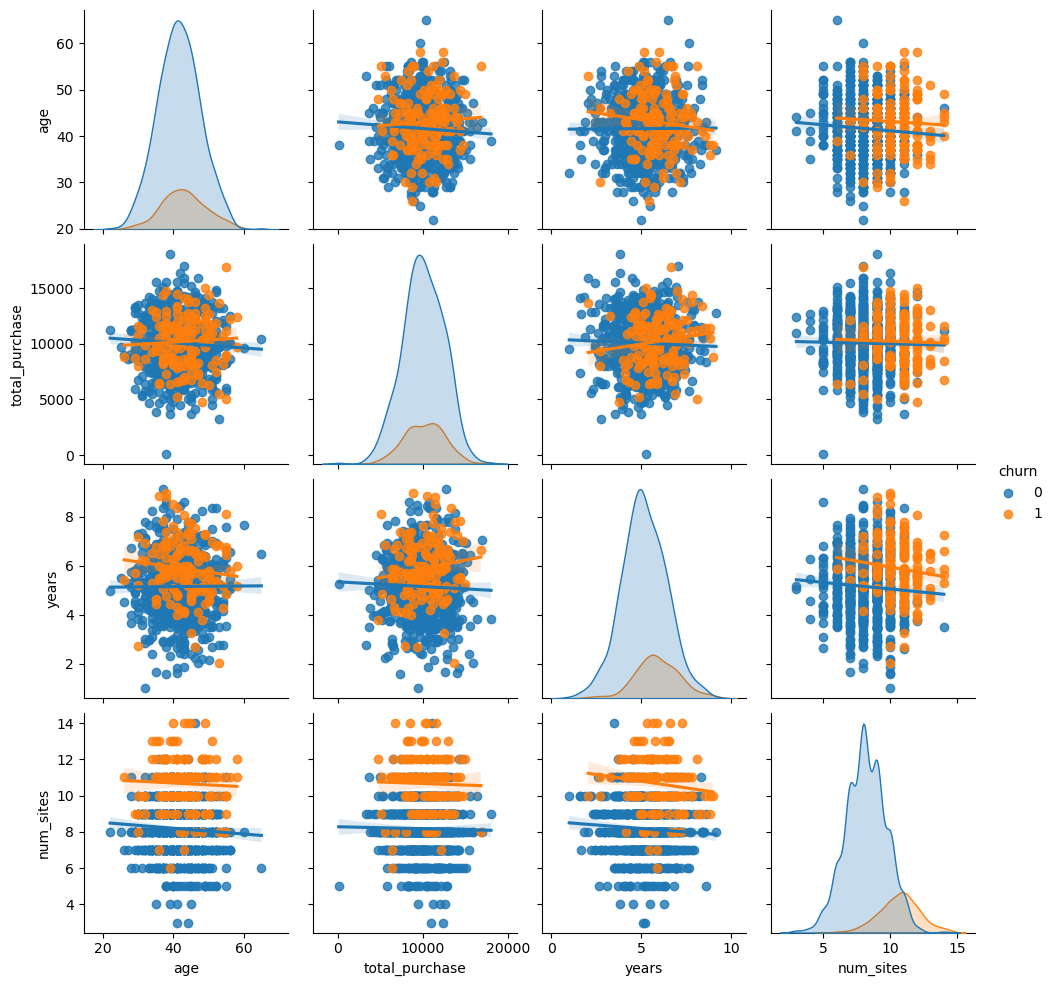

In [23]:
sns.pairplot(KorData, vars = ["age", "total_purchase","years","num_sites"], 
             hue = "churn",
            kind = "reg");

# Veri Ön İşleme

In [24]:
#Empty data check for each column
spark_df.select([sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in spark_df.columns]).show()

+-----+-----+---+--------------+---------------+-----+---------+-----+
|index|names|age|total_purchase|account_manager|years|num_sites|churn|
+-----+-----+---+--------------+---------------+-----+---------+-----+
|    0|    0|  0|             0|              0|    0|        0|    0|
+-----+-----+---+--------------+---------------+-----+---------+-----+



In [25]:
Ind = ["age","total_purchase", "account_manager","years","num_sites"]
vectorAssembler = VectorAssembler(inputCols = Ind, outputCol = "features")
va_df = vectorAssembler.transform(spark_df) #reducing independent variables to a single variable

In [26]:
va_df = va_df.withColumnRenamed("churn","label")

In [27]:
va_df.columns

['index',
 'names',
 'age',
 'total_purchase',
 'account_manager',
 'years',
 'num_sites',
 'label',
 'features']

In [28]:
Final_df = va_df.select(["features","label"])

In [29]:
Final_df.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[42.0,11066.8,0.0...|    1|
|[41.0,11916.22,0....|    1|
|[38.0,12884.75,0....|    1|
|[42.0,8010.76,0.0...|    1|
|[37.0,9191.58,0.0...|    1|
+--------------------+-----+
only showing top 5 rows


### Test-train

In [30]:
Splits = Final_df.randomSplit([0.7,0.3])
Train_df = Splits[0]
Test_df = Splits[1]

# Logistic Regression

In [31]:
Loj = LogisticRegression(featuresCol = "features", labelCol = 'label', maxIter=20)
LojModel = Loj.fit(Train_df)
y_pred = LojModel.transform(Test_df)
ac = y_pred.select("label", "prediction")
ac.filter(ac.label == ac.prediction).count() / ac.count()

0.8664259927797834

## Model Tuning

In [32]:
evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

In [33]:
paramGrid = (ParamGridBuilder()
             .addGrid(Loj.regParam, [0.001, 0.01, 0.1])
             .addGrid(Loj.elasticNetParam, [0.0, 0.5, 1.0])
             .addGrid(Loj.maxIter, [100, 200])
             .build())

In [34]:
gridsearch_cv = CrossValidator(estimator=Loj, 
                               estimatorParamMaps=paramGrid, 
                               evaluator=evaluator, 
                               numFolds=10) 

In [35]:
LjTuneModel = gridsearch_cv.fit(Train_df)

In [36]:
BestModel = LjTuneModel.bestModel

In [37]:
BestModel.getRegParam()

0.001

In [38]:
BestModel.getElasticNetParam()

0.5

In [39]:
BestModel.getMaxIter()

100

In [40]:
BestIter = BestModel.getMaxIter()
BestElastic = BestModel.getElasticNetParam()
BestParam = BestModel.getRegParam()

In [41]:
y_pred = LjTuneModel.transform(Test_df)

In [42]:
FinalAucScore = evaluator.evaluate(y_pred)

In [43]:
FinalAucScore

0.8959726325610312

In [44]:

TrainPredictions = LjTuneModel.transform(Train_df)
TrainAuc = evaluator.evaluate(TrainPredictions)


TestAuc = evaluator.evaluate(y_pred)

print(f"Training Score: {TrainAuc}")
print(f"Test Score: {TestAuc}")

Training Score: 0.9145253242997526
Test Score: 0.8959726325610312


In [48]:
y_pred.groupBy("label", "prediction").count().show() #like Confusion Matrix

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   31|
|    0|       0.0|  212|
|    1|       1.0|   28|
|    0|       1.0|    6|
+-----+----------+-----+



In [49]:
# Let's see the probabilities and predictions side by side
y_pred.select("label", "probability", "prediction").show(20, truncate=False)

+-----+------------------------------------------+----------+
|label|probability                               |prediction|
+-----+------------------------------------------+----------+
|0    |[0.9934966684261511,0.006503331573848858] |0.0       |
|0    |[0.9987211647327017,0.0012788352672983283]|0.0       |
|0    |[0.9996736898926675,3.263101073325281E-4] |0.0       |
|0    |[0.9853676201480325,0.014632379851967525] |0.0       |
|1    |[0.9567671054182757,0.0432328945817243]   |0.0       |
|0    |[0.9990982207630804,9.017792369195865E-4] |0.0       |
|0    |[0.9410862563562865,0.05891374364371349]  |0.0       |
|1    |[0.9864790852378928,0.01352091476210715]  |0.0       |
|0    |[0.9238850405793373,0.07611495942066271]  |0.0       |
|0    |[0.9572482388571864,0.04275176114281365]  |0.0       |
|1    |[0.7894232290656633,0.2105767709343367]   |0.0       |
|0    |[0.9906099485711471,0.009390051428852852] |0.0       |
|0    |[0.9531370701942725,0.04686292980572748]  |0.0       |
|0    |[

In [52]:
for t in [x/100 for x in range(1, 40, 2)]:
    Loj.setThreshold(t)
    ModelT = Loj.fit(Train_df)
    preds = ModelT.transform(Test_df)
    
    # Calculate the optimum f1 score
    evaluator = MulticlassClassificationEvaluator(metricName="fMeasureByLabel",metricLabel=1)
    score = evaluator.evaluate(preds)
    print(f"Threshold: {t:.2f} | F1 Score: {score:.4f}")

Threshold: 0.01 | F1 Score: 0.4361
Threshold: 0.03 | F1 Score: 0.5229
Threshold: 0.05 | F1 Score: 0.5775
Threshold: 0.07 | F1 Score: 0.6012
Threshold: 0.09 | F1 Score: 0.6125
Threshold: 0.11 | F1 Score: 0.6400
Threshold: 0.13 | F1 Score: 0.6483
Threshold: 0.15 | F1 Score: 0.6619
Threshold: 0.17 | F1 Score: 0.6866
Threshold: 0.19 | F1 Score: 0.6870
Threshold: 0.21 | F1 Score: 0.6667
Threshold: 0.23 | F1 Score: 0.6777
Threshold: 0.25 | F1 Score: 0.6723
Threshold: 0.27 | F1 Score: 0.6667
Threshold: 0.29 | F1 Score: 0.6726
Threshold: 0.31 | F1 Score: 0.6545
Threshold: 0.33 | F1 Score: 0.6545
Threshold: 0.35 | F1 Score: 0.6792
Threshold: 0.37 | F1 Score: 0.6731
Threshold: 0.39 | F1 Score: 0.6602


In [53]:
LojFinal = LogisticRegression(
    featuresCol="features", 
    labelCol="label",
    regParam=BestParam,           
    elasticNetParam=BestElastic, 
    maxIter=BestIter,        
    threshold=0.19)            

FinalModel = LojFinal.fit(Train_df)
y_pred_final = FinalModel.transform(Test_df)


y_pred_final.groupBy("label", "prediction").count().show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|   14|
|    0|       0.0|  191|
|    1|       1.0|   45|
|    0|       1.0|   27|
+-----+----------+-----+



In [55]:
# Saving
FinalModel.write().overwrite().save("churn_modelimmm")

In [58]:
print(FinalModel.coefficients)

[0.0653872021755002,6.646381318777323e-05,0.39936885567369096,0.4214680872656263,1.2479228890706007]


In [59]:
print(FinalModel.intercept)

-19.60367907430692
